# Parcial: Curso Análisis Predictivo de Series Temporales

## Posgrado de Big Data

## Universidad ORT Uruguay

### Curso 2025 - 15/7/2025.

## Estudiante: (completar)

In [1]:
## Ejemplo: instalación de astsadata usando pip:
#!pip install astsadata
#Importo astsadata
import warnings
with warnings.catch_warnings(action="ignore"):
    import astsadata as astsa
    

## Ajusto tamaño de figuras
import matplotlib.pyplot as plt
import astsadata as astsa
import numpy as np
import statsmodels.api as sm
import pandas as pd

plt.rcParams['figure.figsize'] = [15,5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

#### Funciones útiles

In [2]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.formula.api import ols

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)

    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    ylabel = "CCF"

    if ax is None:
        ax = plt.gca()
    
    ax.stem(lags, ccf, basefmt="k")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags,conf_level,-conf_level,alpha=0.25)
    ax.set_xlabel("LAG")
    ax.set_ylabel(ylabel)

    
    return ax

def periodogram(x,sampling_frequency=1):

    """Función que calcula el periodograma y grafica.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    plt.plot(f,P);
    plt.xlabel("Frequency")
    plt.ylabel("Power")


def spectrum(x,sampling_frequency=1, nfreq=10):

    """Función que calcula las componentes más relevantes del periodograma.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    nfreq = np.minimum(nfreq,round(n/2)) #corto nfreq si la serie es muy corta!
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1] #ordeno P decreciente
    return pd.DataFrame({"Frecuencia" : f[index[0:nfreq]],"Potencia" : P[index[0:nfreq]]})

## Ejercicio 1

Se considera la serie `tmort` de la biblioteca `astsa`, que registra la mortalidad global en Los Angeles con frecuencia semanal que se grafica abajo.

1. Realizar un ajuste de tendencia lineal para la serie. Discutir el resultado.
2. Agregar un término de tendencia cuadrática $x = \beta_0 + \beta_1 t + \beta_2 t^2 + w_t$ y discutir si mejora respecto al anterior.
3. Realizar un periodograma de los residuos para encontrar componentes estacionales (por ej. anuales).
4. Incluir en la regresión tanto los términos de tendencia como estacionales que considere adecuados y realizar el ajuste.
5. Discutir los residuos obtenidos. ¿Queda información por extraer? (No se pide realizar más ajustes)

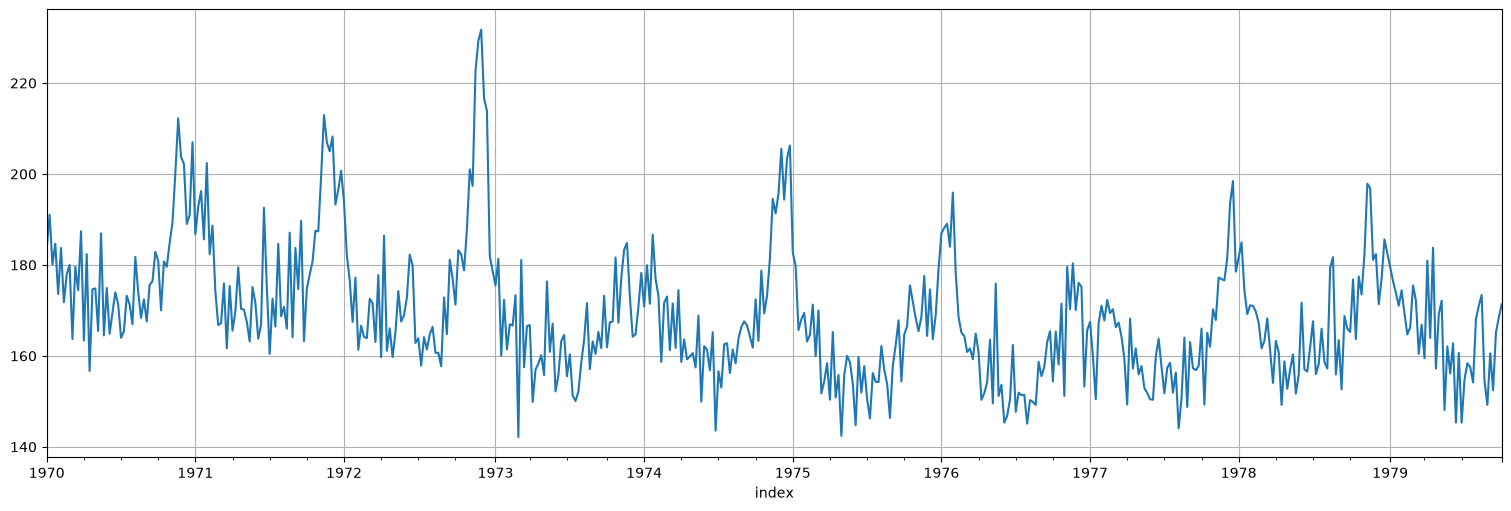

In [3]:
x = astsa.lap.tmort
x.plot();

In [4]:
x.head()

index
1969-12-29/1970-01-04    183.63
1970-01-05/1970-01-11    191.05
1970-01-12/1970-01-18    180.09
1970-01-19/1970-01-25    184.67
1970-01-26/1970-02-01    173.60
Freq: W-SUN, Name: tmort, dtype: float64

In [5]:
df_x = pd.DataFrame({"tmort":x,"t":np.arange(0,x.size)})

Ejercicio 1.1:

In [6]:
fit_linear = ols("tmort ~ t",data=df_x).fit()
fit_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     70.45
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           4.76e-16
Time:                        18:24:10   Log-Likelihood:                -2034.4
No. Observations:                 508   AIC:                             4073.
Df Residuals:                     506   BIC:                             4081.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    177.6107      1.179    150.704      0.000     175.295     179.926
t             -0.0338      0.004     -8.393      0.000      -0.042      -0.026
==============================================================================
Omnibus:                       90.127   Durbin-Watson:                   0.619
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              155.537
Skew:                           1.054   Prob(JB):                     1.68e-34
Kurtosis:                       4.704   Cond. No.                         585.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='index'>

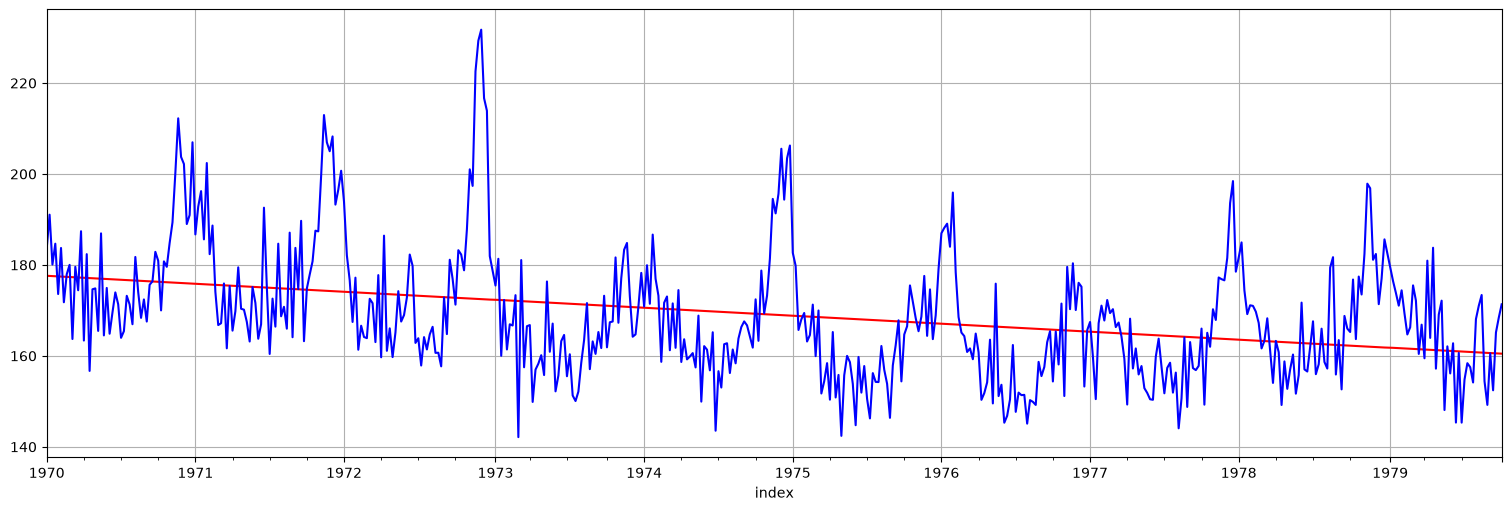

In [7]:
fit_linear.fittedvalues.plot(label="Ajuste lineal",color="red")
df_x.tmort.plot(label="tmort",color="blue")

Se observa una tendencia decreciente (-0.0338) significativa con p valor 0, el modelo explica el 0.12% de la varianza de la serie 

<Axes: xlabel='index'>

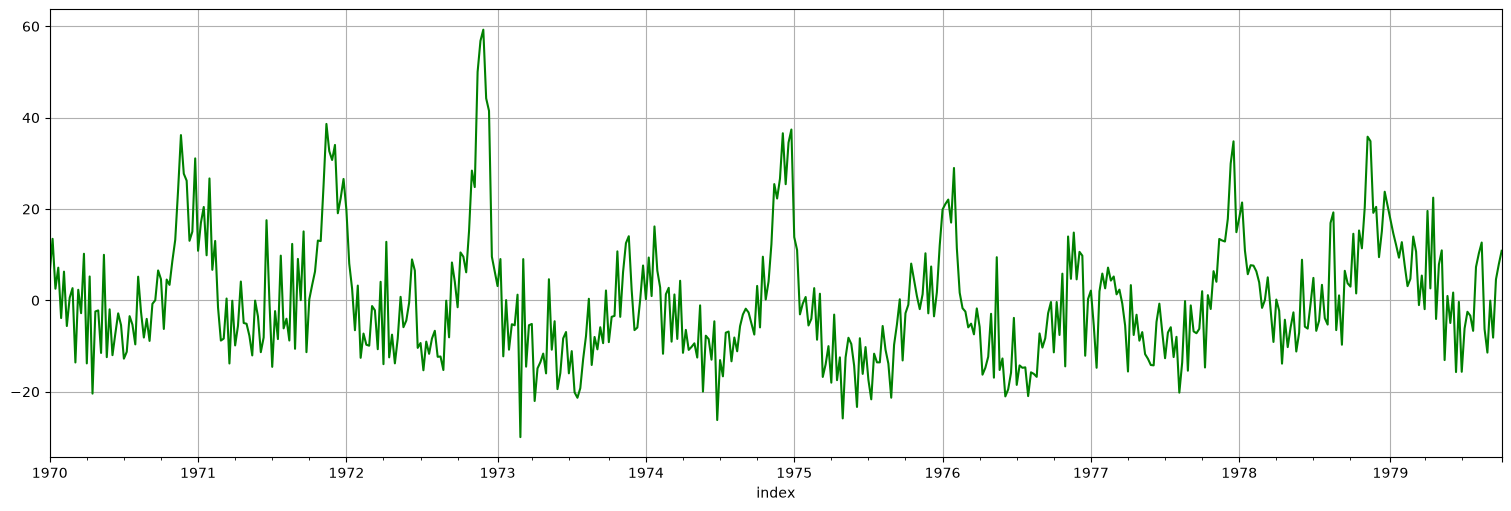

In [8]:
fit_linear.resid.plot(label="Residuales",color="green")

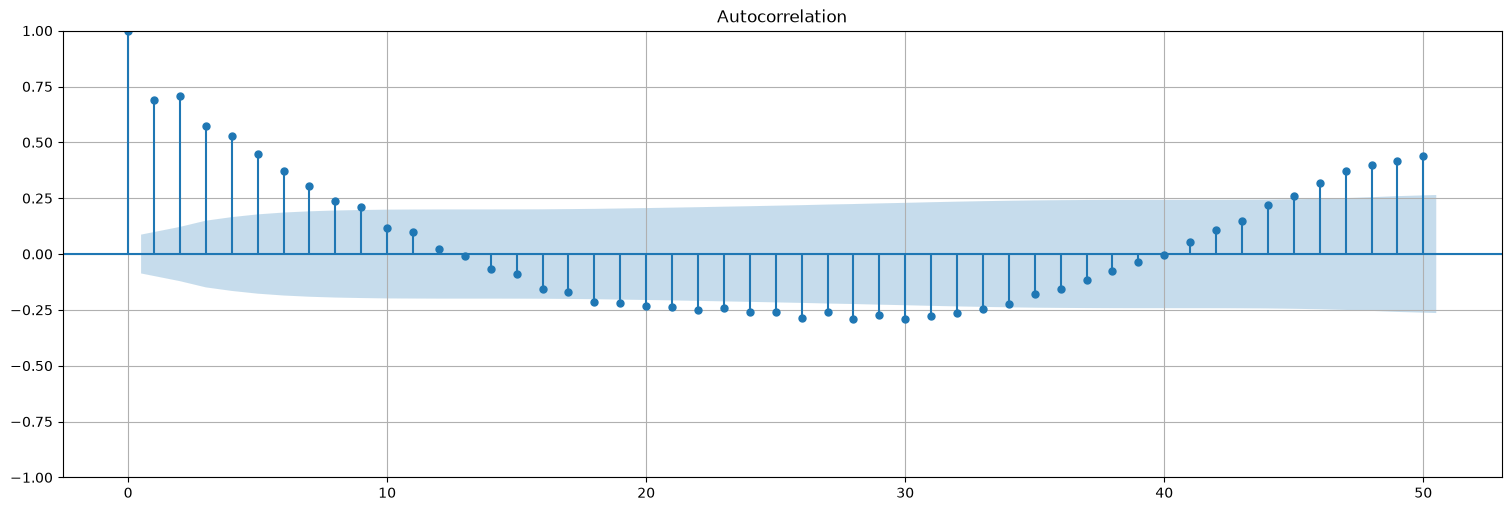

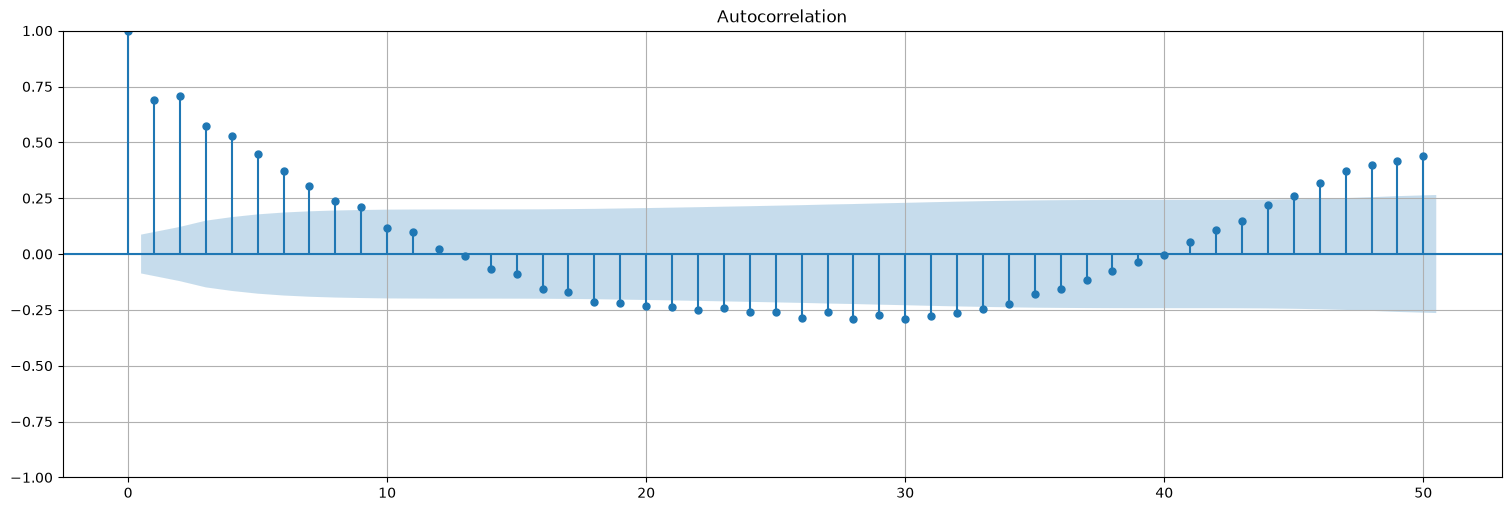

In [9]:
plot_acf(fit_linear.resid,lags=50)

Se observa una clara autocorrelacion entre los residuos y en el grafico de residuos se puede observar lo que parecen ser periodos, por lo que aun falta modelar información.

Ejercicio 1.2

In [10]:
fit_squared = ols("tmort ~ t + I(t**2)",data=df_x).fit()
fit_squared.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     45.00
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.04e-18
Time:                        18:24:12   Log-Likelihood:                -2025.9
No. Observations:                 508   AIC:                             4058.
Df Residuals:                     505   BIC:                             4070.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    182.9787      1.736    105.417      0.000     179.568     186.389
t             -0.0974      0.016     -6.161      0.000      -0.129      -0.066
I(t ** 2)      0.0001   3.02e-05      4.157      0.000    6.62e-05       0.000
==============================================================================
Omnibus:                      110.048   Durbin-Watson:                   0.640
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              220.759
Skew:                           1.186   Prob(JB):                     1.16e-48
Kurtosis:                       5.192   Cond. No.                     3.44e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.44e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='index'>

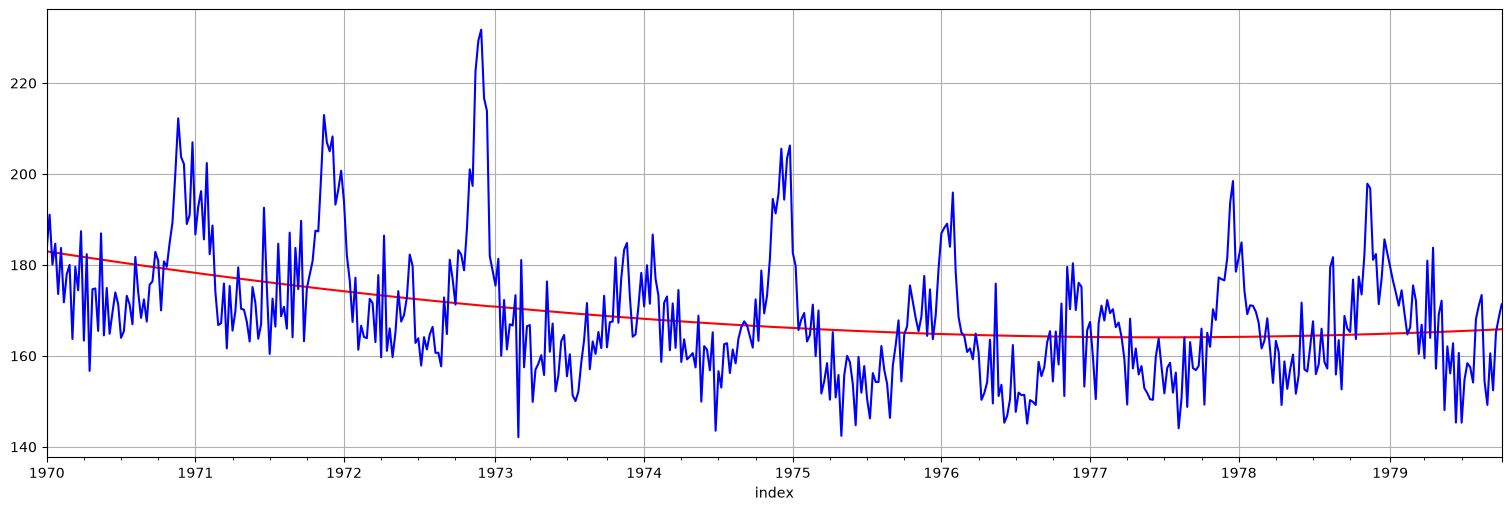

In [11]:
fit_squared.fittedvalues.plot(label="Ajuste cuadrático",color="red")
df_x.tmort.plot(label="tmort",color="blue")

In [12]:
print(fit_linear.aic)
print(fit_squared.aic)

4072.888806244227
4057.793887165055


In [13]:
#MSE de ambos modelos
print("MSE Modelo Lineal:", np.mean(fit_linear.resid**2))
print("MSE Modelo Cuadrático:", np.mean(fit_squared.resid**2))

MSE Modelo Lineal: 176.22235316791307
MSE Modelo Cuadrático: 170.39089032285142


El modelo cuadratico tiene < AIC y MSE, los coeficientes son significativos por lo que es un mejor modelo que el lineal en funcion del tiempo.

Ejercicio 1.3 y 1.4

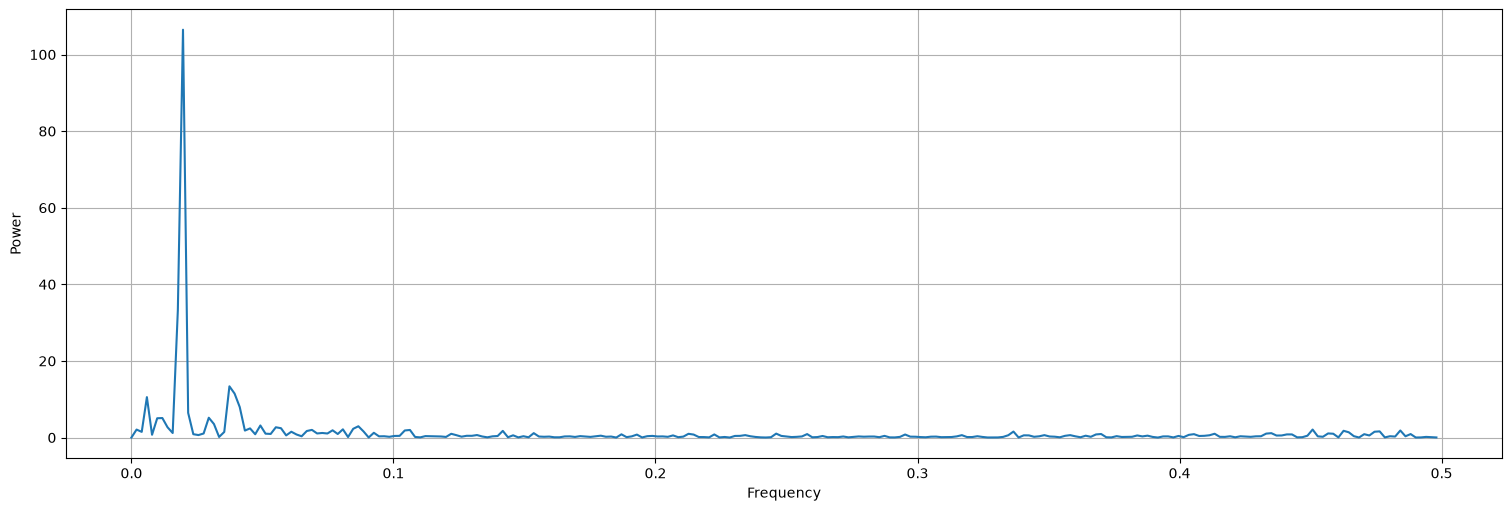

In [14]:
periodogram(fit_squared.resid,sampling_frequency=1)

In [15]:
spectrum(fit_squared.resid,sampling_frequency=1,nfreq=10)

,Frecuencia,Potencia
0,0.019685,106.473055
1,0.017717,33.203015
2,0.037402,13.374765
3,0.039370,11.484574
4,0.005906,10.551783
5,0.041339,7.967111
6,0.021654,6.449279
7,0.029528,5.174904
8,0.011811,5.091853
9,0.009843,5.037416


In [16]:
frecuencias = spectrum(fit_squared.resid,sampling_frequency=1,nfreq=10).Frecuencia[0:3]

In [17]:
print(frecuencias)

0    0.019685
1    0.017717
2    0.037402
Name: Frecuencia, dtype: float64


In [18]:
t = np.arange(len(df_x))
for i, f in enumerate(frecuencias, start=1):
    df_x[f'sin{i}'] = np.sin(2*np.pi*f*t)
    df_x[f'cos{i}'] = np.cos(2*np.pi*f*t)

In [19]:
fit_period = ols("tmort ~ t + I(t**2) + sin1 + cos1 + sin2 + cos2 + sin3 + cos3",data=df_x).fit()

In [20]:
fit_period.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     71.04
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.67e-77
Time:                        18:24:13   Log-Likelihood:                -1874.4
No. Observations:                 508   AIC:                             3767.
Df Residuals:                     499   BIC:                             3805.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    183.0733      1.299    140.887      0.000     180.520     185.626
t             -0.0974      0.012     -8.246      0.000      -0.121      -0.074
I(t ** 2)      0.0001   2.26e-05      5.518      0.000    8.01e-05       0.000
sin1           3.0784      0.615      5.004      0.000       1.870       4.287
cos1           9.8456      0.613     16.051      0.000       8.640      11.051
sin2          -2.8997      0.616     -4.710      0.000      -4.109      -1.690
cos2          -4.9855      0.613     -8.128      0.000      -6.191      -3.780
sin3          -2.8835      0.614     -4.697      0.000      -4.090      -1.677
cos3          -2.2560      0.613     -3.678      0.000      -3.461      -1.051
==============================================================================
Omnibus:                       51.891   Durbin-Watson:                   1.147
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              100.327
Skew:                           0.610   Prob(JB):                     1.64e-22
Kurtosis:                       4.803   Cond. No.                     3.45e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.45e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='index'>

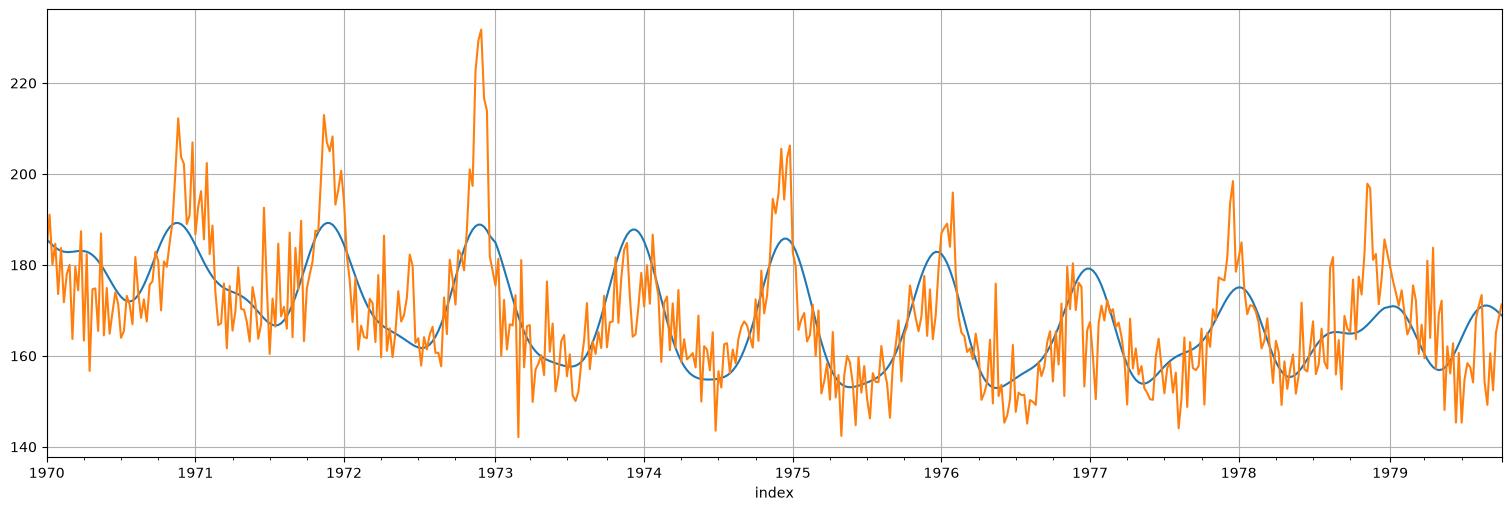

In [21]:
fit_period.fittedvalues.plot()
df_x.tmort.plot()

In [22]:
#MSE de los 3 modelos
print("MSE Modelo Lineal:", np.mean(fit_linear.resid**2))
print("MSE Modelo Cuadrático:", np.mean(fit_squared.resid**2))
print("MSE Modelo con periodos:", np.mean(fit_period.resid**2))

MSE Modelo Lineal: 176.22235316791307
MSE Modelo Cuadrático: 170.39089032285142
MSE Modelo con periodos: 93.85833308783037


Ejercicio 1.5

<Axes: xlabel='index'>

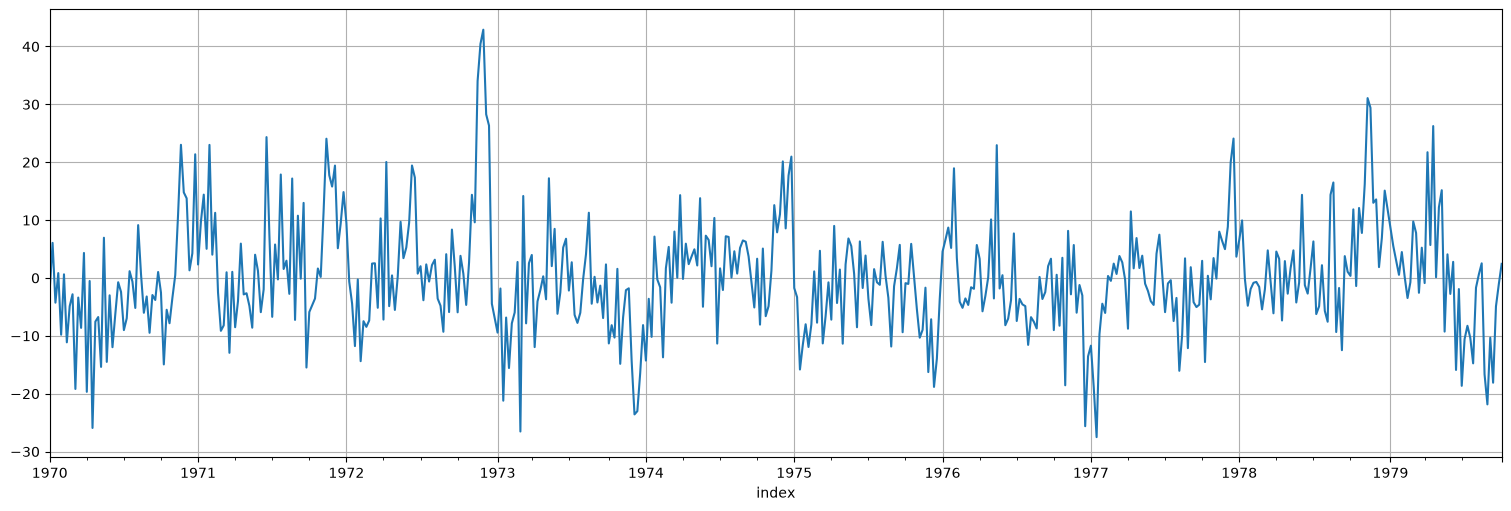

In [23]:
fit_period.resid.plot()

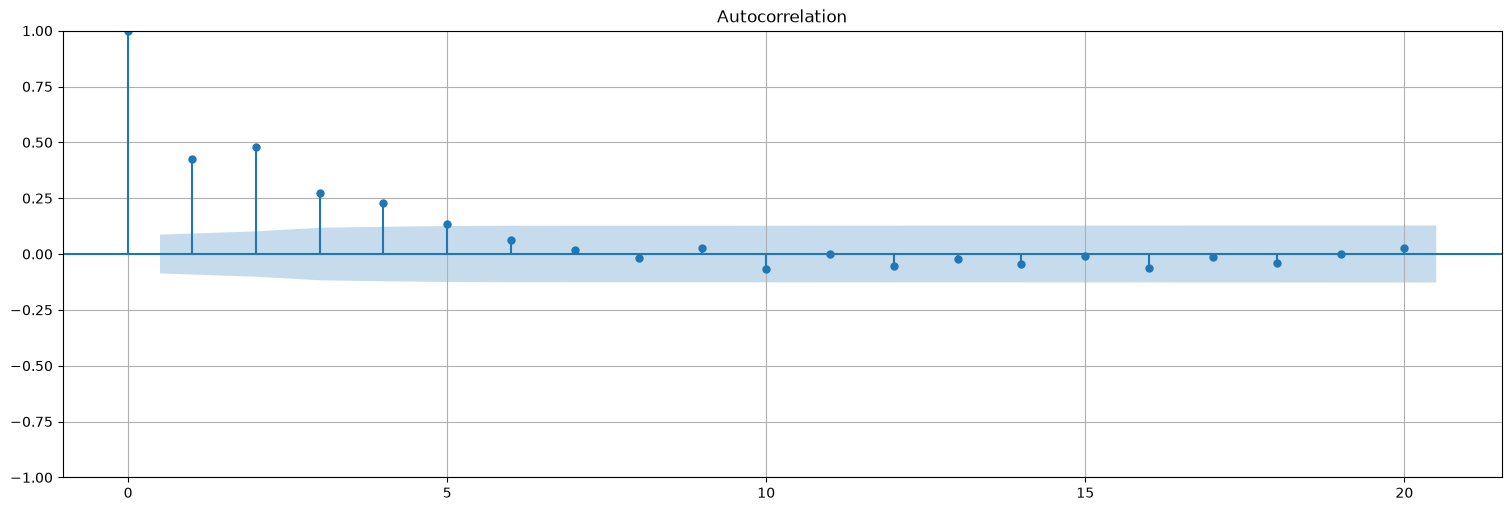

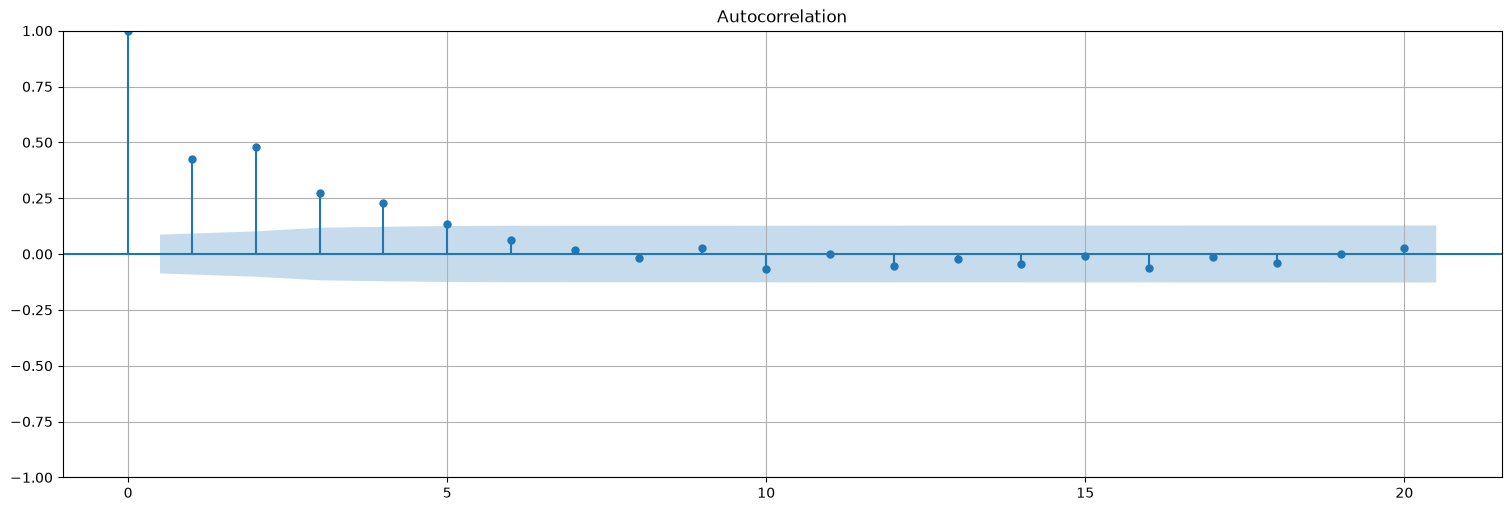

In [24]:
plot_acf(fit_period.resid,lags = 20)

In [25]:
from statsmodels.graphics.api import qqplot

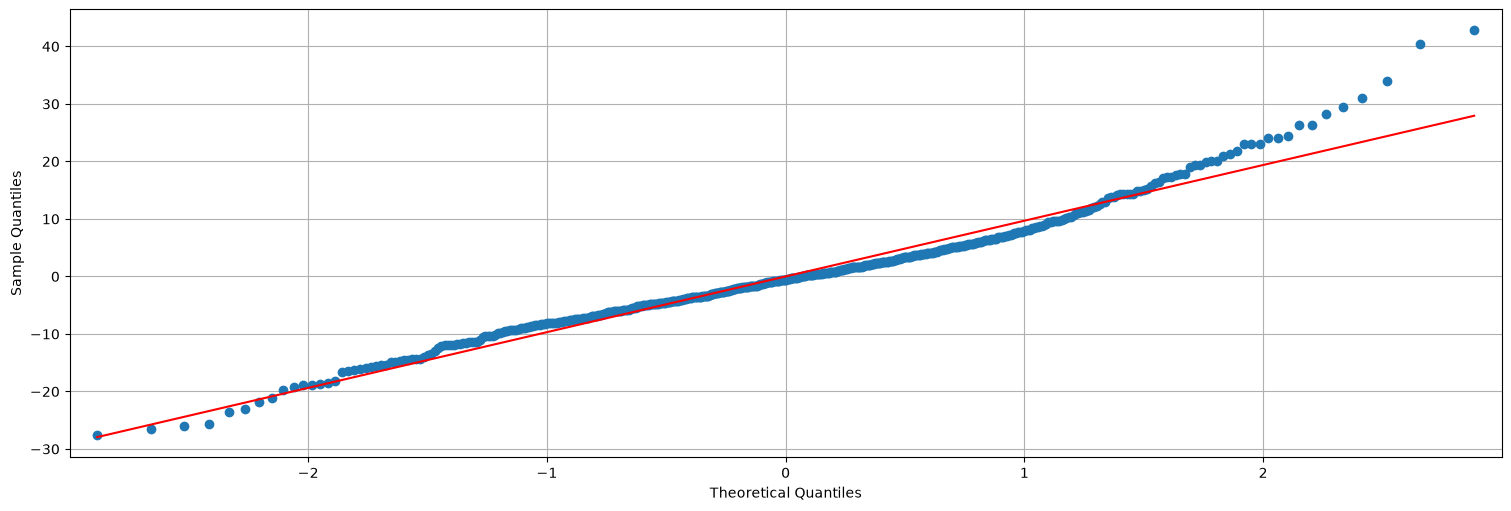

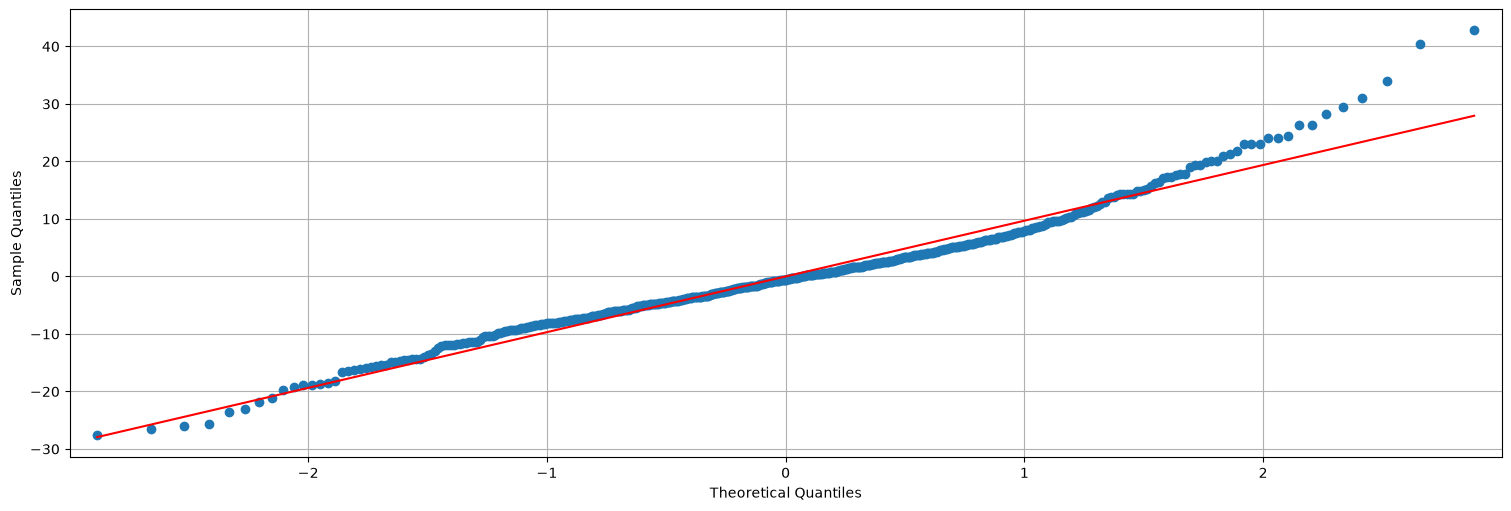

In [26]:
qqplot(fit_period.resid, line='s')

Se sigue observanddo correlacion en la ACF de los residuos que decrece a partir del lag 4 (1 mes), todavía hay información para extraer de la serie

## Ejercicio 2

Se considera la serie del producto interno bruto de EEUU medido trimestralmente.

1. Realizar una transformación de tipo $\nabla \log()$ para calcular el incremento porcentual aproximado.
2. Discutir brevemente si la serie resultante es estacionaria y si está o no centrada en 0.
3. Realizar un análisis de la autocorrelación y autocorrelación parcial.
4. Realizar un ajuste a un modelo $ARMA(p,q)$ adecuado. Puede incorporar dos modelos para comparar.
5. Analizar los residuos resultantes.
6. Realizar una predicción para el año siguiente.

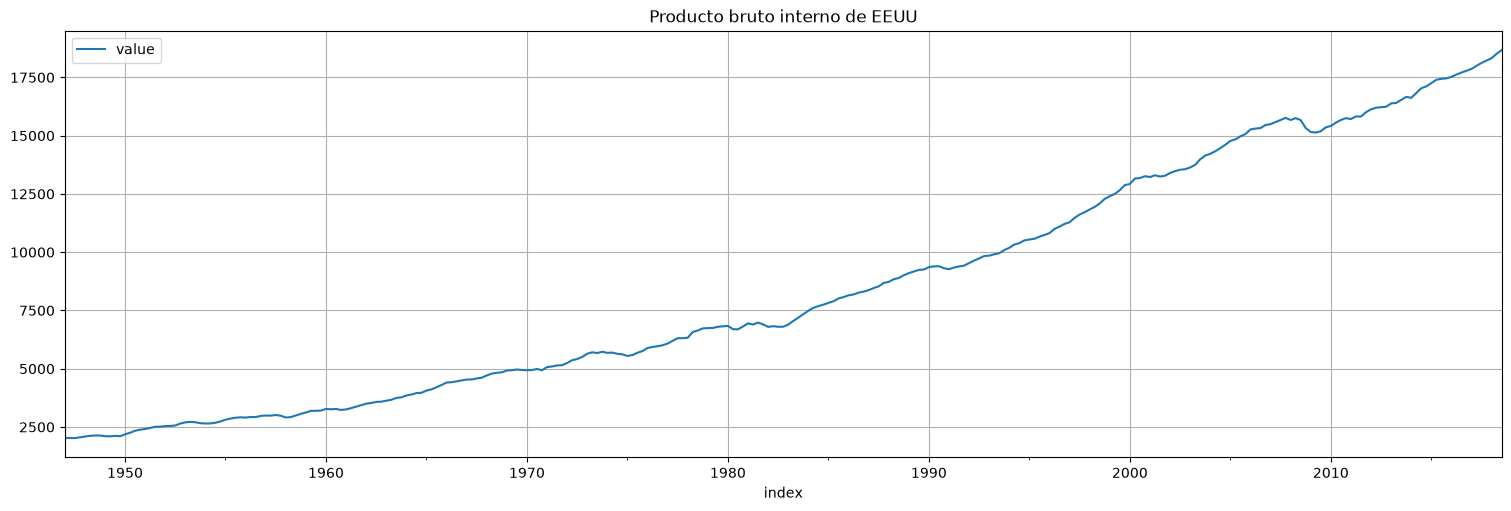

In [27]:
x=astsa.gdp
x.plot();
plt.title("Producto bruto interno de EEUU");

Ejercicio 2.1 y 2.2

In [28]:
log = np.log(x.value)
diff_log = log.diff().dropna()
df_x = pd.DataFrame({"gdp":diff_log,"t":np.arange(0,diff_log.size)})

In [29]:
df_x.head()

,gdp,t
index,,
1947Q2,-0.002670,0
1947Q3,-0.002067,1
1947Q4,0.015521,2
1948Q1,0.014931,3
1948Q2,0.016372,4


[]

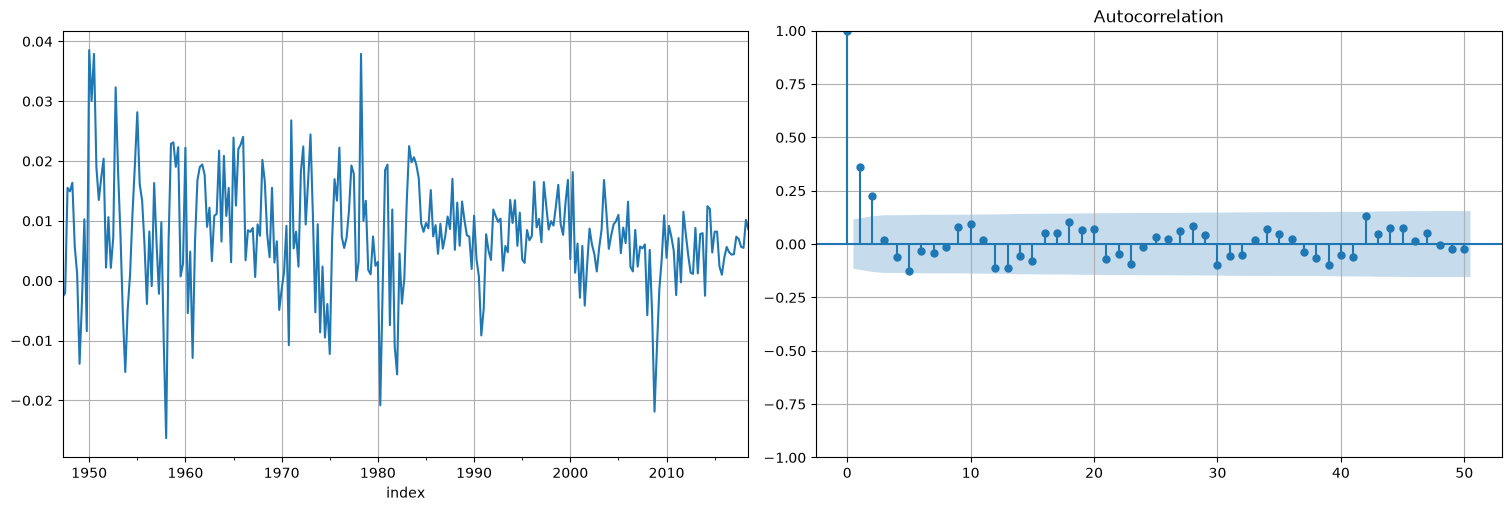

In [30]:
fig,axs = plt.subplots(1, 2)
df_x.gdp.plot(ax=axs[0])
plot_acf(df_x.gdp,lags=50,ax=axs[1])
plt.plot()

La serie claramente no está centrada en 0 y no es estacionaria ya que se ve que hay autocorrelacion hasta lag 2

Ejercicio 2.3

[]

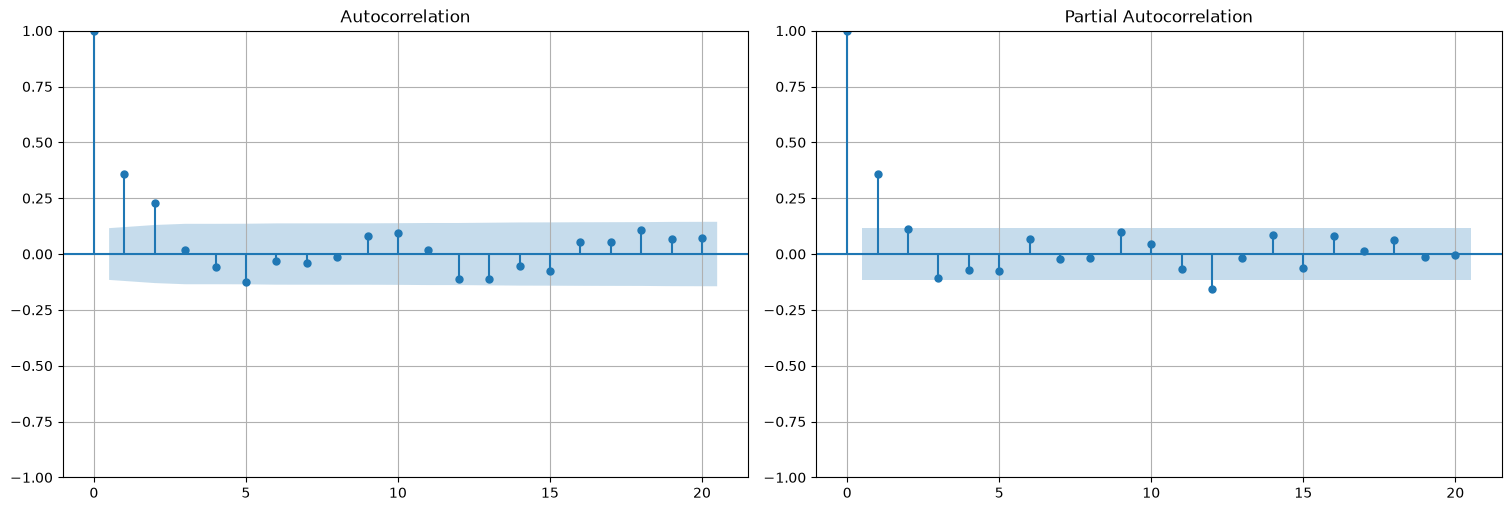

In [31]:
fig,axs = plt.subplots(1, 2)
plot_acf(df_x.gdp, lags=20, ax=axs[0], bartlett_confint=True);
plot_pacf(df_x.gdp,lags=20,ax=axs[1])
plt.plot()

Se observa que la ACF presenta autocorrelacion hasta lag 2, mientras que la PACF hasta lag 1

Ejercicio 2.4

In [32]:
ordenes = [(1,0,0),(2,0,0),(1,0,1),(1,0,2)]
for o in ordenes:
    model = sm.tsa.ARIMA(df_x.gdp, order=o)
    results = model.fit()
    print(f"Orden: {o}, AIC: {results.aic}, BIC: {results.bic}")

Orden: (1, 0, 0), AIC: -1894.9310032488474, BIC: -1883.963027816388


Orden: (2, 0, 0), AIC: -1896.598749618979, BIC: -1881.9747823756995
Orden: (1, 0, 1), AIC: -1894.9766346519482, BIC: -1880.3526674086688


Orden: (1, 0, 2), AIC: -1897.7047641986892, BIC: -1879.42480514459


(1,0,1) y (1,0,2) parecen ser los mejores modelos considerando AIC y BIC

In [33]:
arma_1 = sm.tsa.ARIMA(df_x.gdp, order=(1,0,1)).fit()
arma_2 = sm.tsa.ARIMA(df_x.gdp, order=(1,0,2)).fit()

print(arma_1.summary())
print(arma_2.summary())

                               SARIMAX Results                                
Dep. Variable:                    gdp   No. Observations:                  286
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 951.488
Date:                Sun, 12 Jul 2026   AIC                          -1894.977
Time:                        18:24:19   BIC                          -1880.353
Sample:                    06-30-1947   HQIC                         -1889.115
                         - 09-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.001      8.386      0.000       0.006       0.010
ar.L1          0.5423      0.125      4.330      0.000       0.297       0.788
ma.L1         -0.2006      0.139     -1.438      0.1

El coeficiente de MA parece no ser significativo, por lo que ajustamos con un AR(1)

In [34]:
arma_ar_1 = sm.tsa.ARIMA(df_x.gdp, order=(1,0,0)).fit()
arma_ar_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    gdp   No. Observations:                  286
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 950.466
Date:                Sun, 12 Jul 2026   AIC                          -1894.931
Time:                        18:24:19   BIC                          -1883.963
Sample:                    06-30-1947   HQIC                         -1890.535
                         - 09-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.001      9.466      0.000       0.006       0.009
ar.L1          0.3600      0.048      7.567      0.000       0.267       0.453
sigma2       7.59e-05   4.56e-06     16.646      0.000     6.7e-05    8.48e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.47   Jarque-Bera (JB):                43.53
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

[]

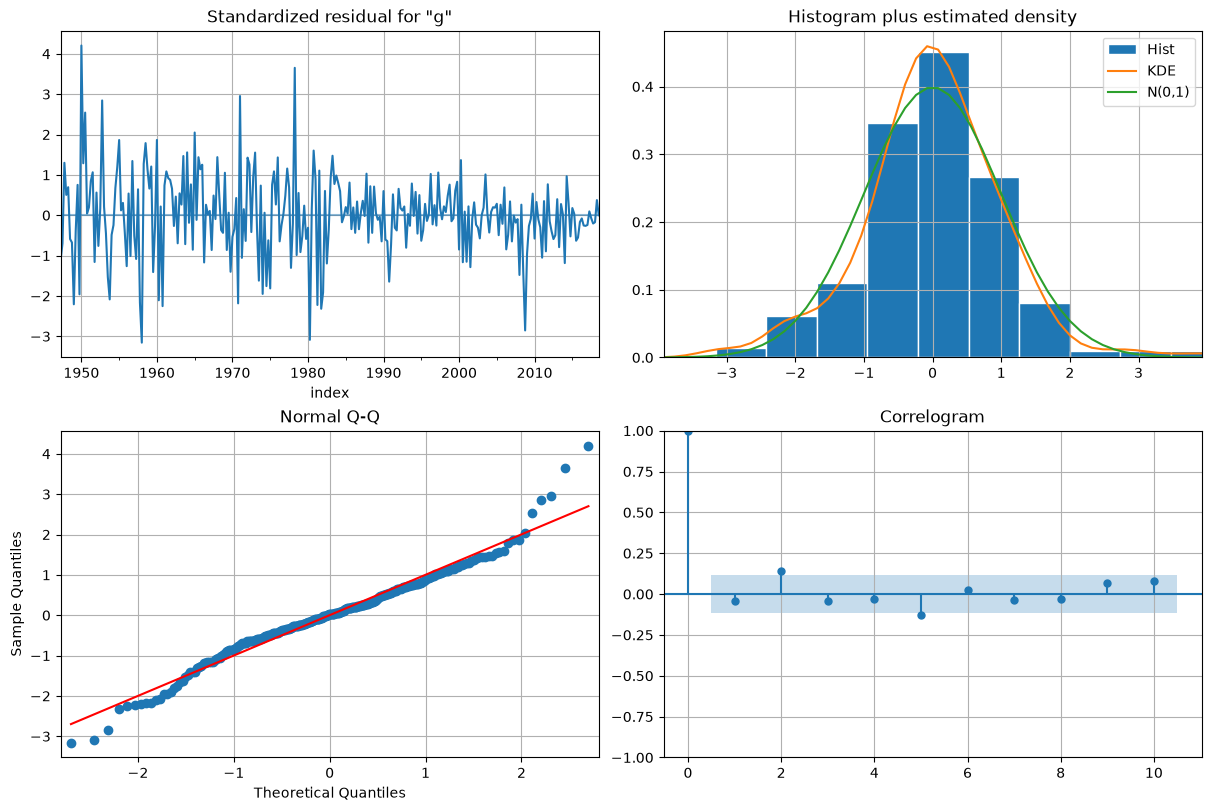

In [35]:
arma_ar_1.plot_diagnostics(figsize=(12, 8))
plt.plot()

In [36]:
print(sm.stats.acorr_ljungbox(arma_ar_1.resid, lags=[10,20]))

      lb_stat  lb_pvalue
10  15.869783   0.103421
20  31.616971   0.047555


Los residuos estan centrados en 0, el correlograma sugiere ruido blanco

Prediccion para el año siguiente

In [37]:
fc = arma_ar_1.get_forecast(steps=4)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
print(pd.DataFrame({'prediccion': pred, 'IC_inf': ci.iloc[:, 0], 'IC_sup': ci.iloc[:, 1]}))

        prediccion    IC_inf    IC_sup
2018Q4    0.008044 -0.009031  0.025120
2019Q1    0.007843 -0.010305  0.025992
2019Q2    0.007771 -0.010512  0.026054
2019Q3    0.007745 -0.010555  0.026045


[]

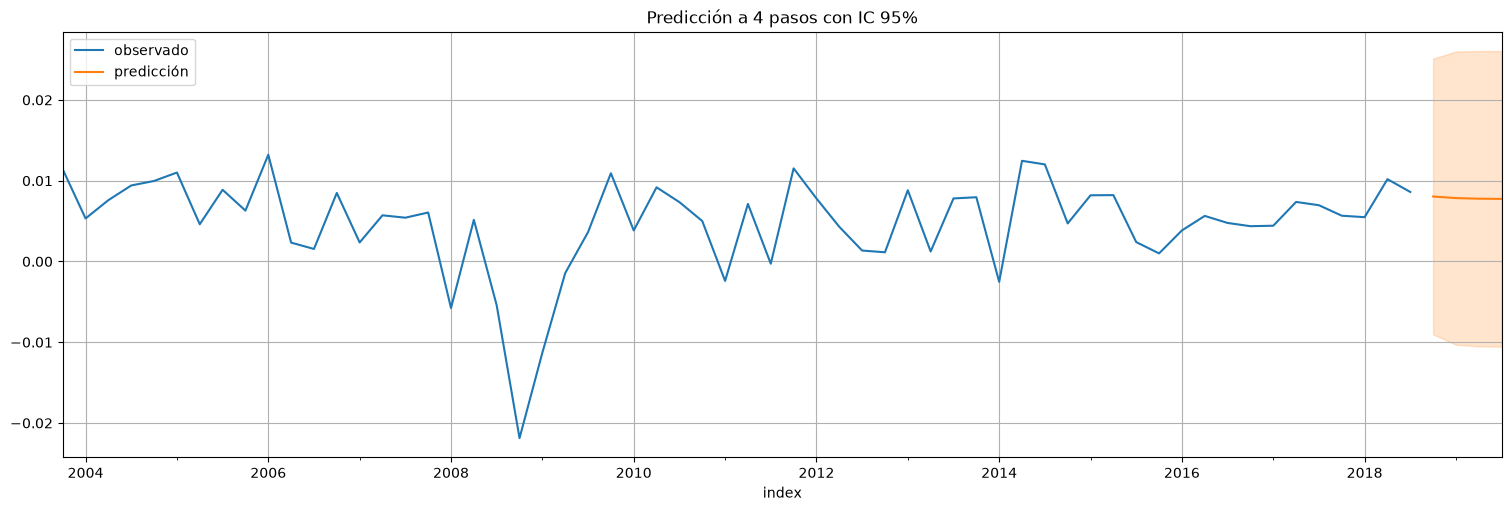

In [38]:
ax = df_x.gdp[-60:].plot(label='observado')
pred.plot(ax=ax, label='predicción', color='C1')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='C1', alpha=0.2)
ax.legend()
ax.set_title(f'Predicción a {4} pasos con IC 95%');
plt.plot()

## Ejercicio 3

Se considera la serie de $x$ de crecimiento relativo (calculado como $\nabla \log (z)$) del consumo privado en la economía de EEUU y la serie análoga $y$ de crecimiento relativo del desempleo.

1. Analice la correlación cruzada entre ambas series.
2. ¿Para que valor de lag se da la mayor correlación entre ambas?
3. Se propone un modelo de la forma $y_t = \beta_0 + \beta_1 x_{t-l} + w_t$ con $x$ e $y$ como antes y $l$ el lag de la parte anterior. Realice un ajuste lineal para estimar los parámetros $\beta_0$ y $\beta_1$.
4. ¿Cuánto de la varianza de la serie original se explica por la relación entre $x$ e $y$?
5. Realice un gráfico de la predicción del modelo (no olvide que la primera predicción será luego de $l$ lags) y el crecimiento relativo del desempleo observado. 
6. Analice los residuos del modelo y discuta si aún queda información por ajustar.

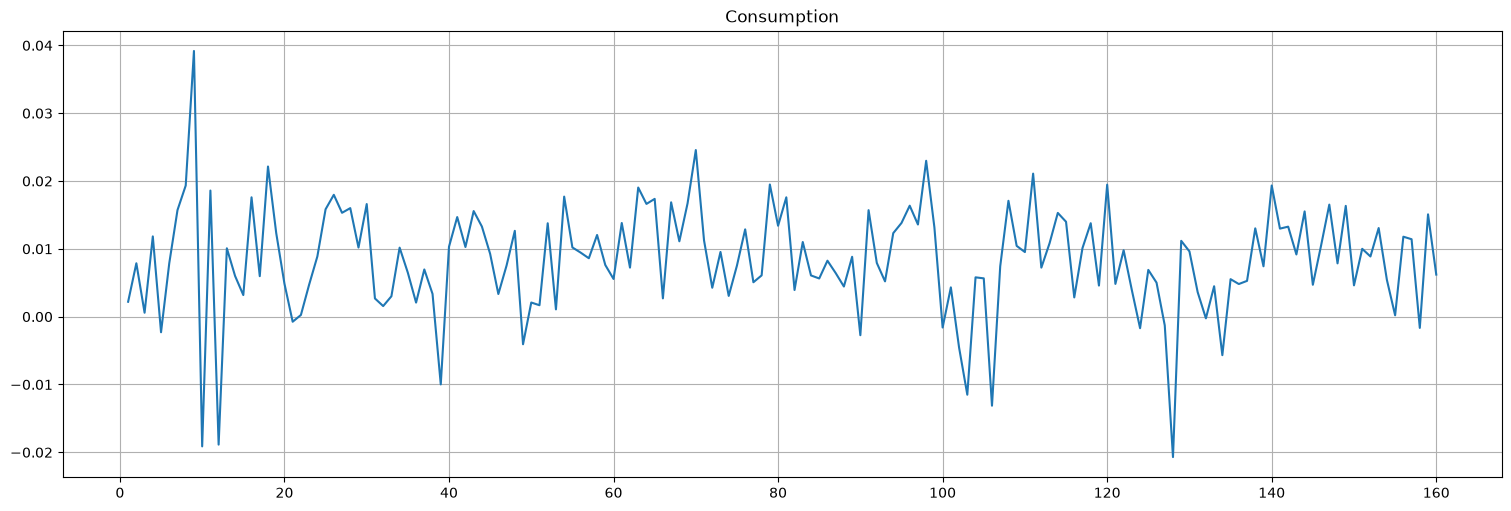

In [39]:
x=np.log(astsa.econ5["consum"]).diff()
y=np.log(astsa.econ5["unemp"]).diff()
x.plot();
plt.title("Consumption");

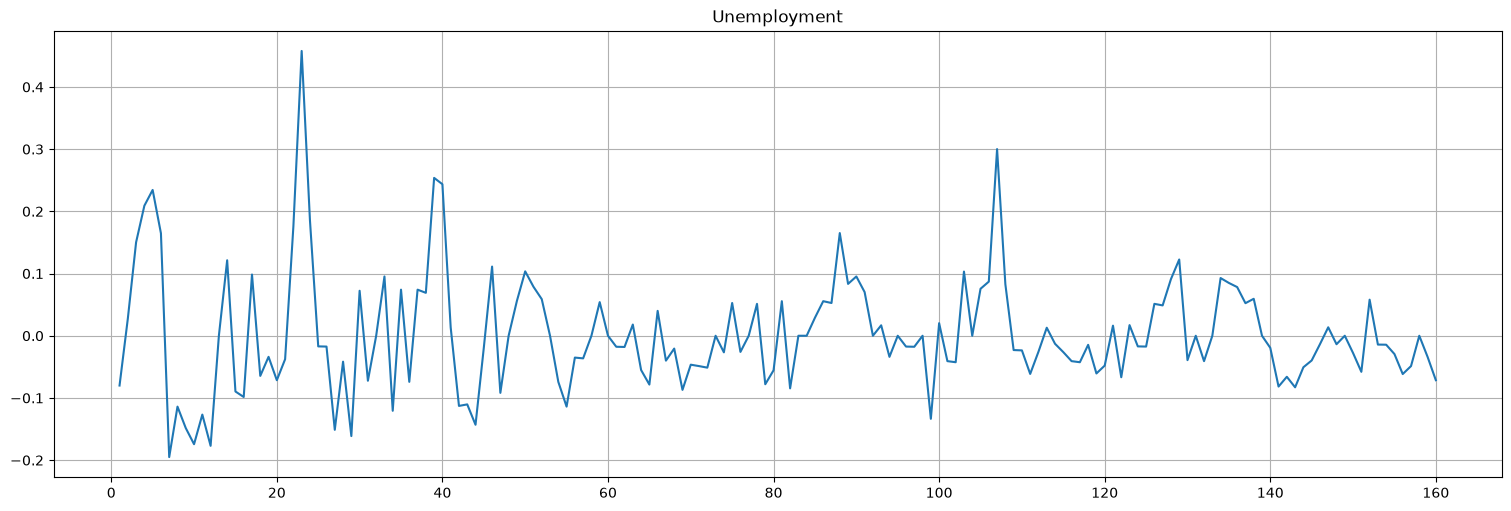

In [40]:
y.plot();
plt.title("Unemployment");

In [41]:
df = pd.DataFrame({"consum":x,"unemp":y,"t":np.arange(0,x.size)})

In [42]:
x.head()

0         NaN
1    0.002199
2    0.007876
3    0.000581
4    0.011836
Name: consum, dtype: float64

In [43]:
y.head()

0         NaN
1   -0.080043
2    0.027399
3    0.150282
4    0.209092
Name: unemp, dtype: float64

Correlacion Cruzada

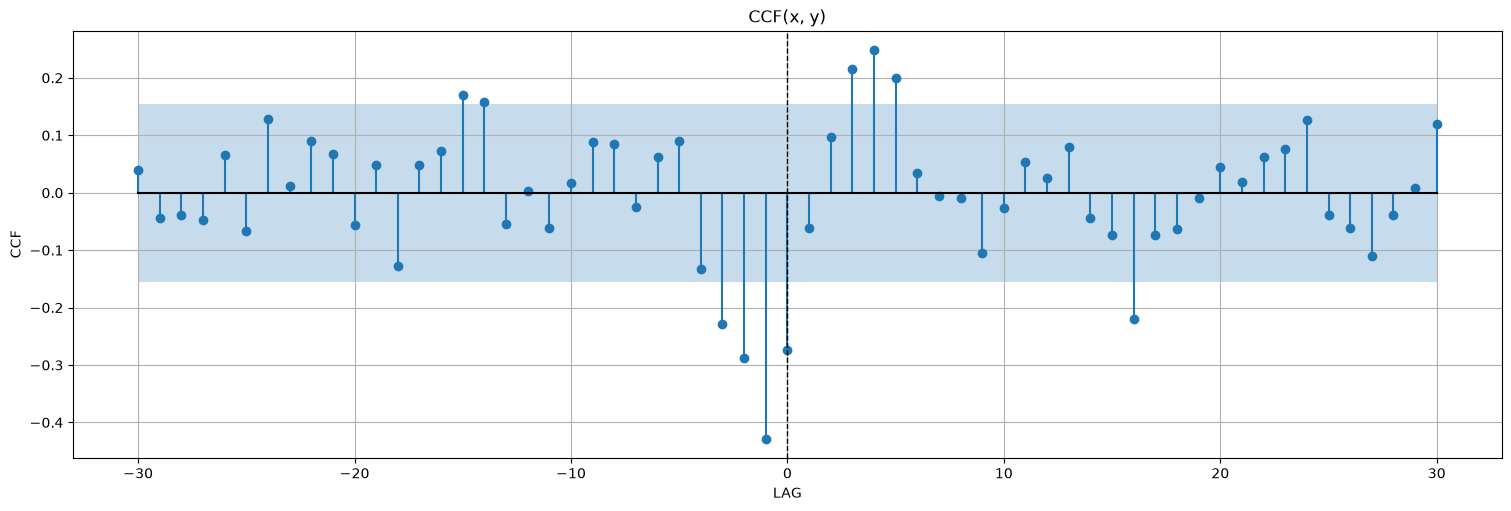

In [44]:
plt.figure()
ccf(df.consum.dropna(), df.unemp.dropna(), max_lag=30)
plt.title('CCF(x, y)');

In [45]:
# §C2: lag de máxima correlación — corr(y_t, x_{t-l})
cors = pd.Series({l: df.unemp.dropna().corr(df.consum.dropna().shift(l)) for l in range(-13, 13)})
print(cors)
l_opt = int(cors.abs().idxmax())          # usar cors.abs().idxmax() si la correlación fuerte es negativa
print()
print(f'Lag óptimo: l = {l_opt} | corr = {cors[l_opt]:.3f}')

-13    0.094116
-12    0.031086
-11    0.061031
-10   -0.029247
-9    -0.112545
-8    -0.010003
-7    -0.005581
-6     0.034953
-5     0.203206
-4     0.250455
-3     0.216637
-2     0.098147
-1    -0.061882
0     -0.273686
1     -0.429115
2     -0.289783
3     -0.233511
4     -0.136770
5      0.095543
6      0.067050
7     -0.026729
8      0.093573
9      0.097707
10     0.018663
11    -0.069199
12     0.002661
dtype: float64

Lag óptimo: l = 1 | corr = -0.429


Se observa que "x lidera a y" por 1 lag, es decir que x puede servir para predecir el valor de y en el periodo siguiente

3. Se propone un modelo de la forma $y_t = \beta_0 + \beta_1 x_{t-l} + w_t$ con $x$ e $y$ como antes y $l$ el lag de la parte anterior. Realice un ajuste lineal para estimar los parámetros $\beta_0$ y $\beta_1$.
4. ¿Cuánto de la varianza de la serie original se explica por la relación entre $x$ e $y$?

In [46]:
# Ajuste lineal con el lag óptimo hallado arriba (l_opt), no hardcodeado
datos = pd.DataFrame({'unemp': df.unemp, 'consum_lag': df.consum.shift(l_opt)}).dropna()
fit_propuesto = ols('unemp ~ consum_lag', data=datos).fit()
fit_propuesto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  unemp   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     35.43
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.66e-08
Time:                        18:24:22   Log-Likelihood:                 169.54
No. Observations:                 159   AIC:                            -335.1
Df Residuals:                     157   BIC:                            -329.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0435      0.010      4.545      0.000       0.025       0.062
consum_lag    -4.8982      0.823     -5.953      0.000      -6.523      -3.273
==============================================================================
Omnibus:                       38.424   Durbin-Watson:                   1.479
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              120.469
Skew:                           0.901   Prob(JB):                     6.93e-27
Kurtosis:                       6.865   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El coeficiente de `consum_lag` es β₁ = -4.898 (error estándar 0.823, t=-5.95, p<0.001): significativo y negativo, es decir que un mayor crecimiento del consumo hoy se asocia a una **caída** del crecimiento del desempleo un trimestre después (β₀ = 0.0435, p<0.001). R² = 0.184: el modelo explica el **18.4%** de la varianza de `unemp` — coincide con el cuadrado de la correlación hallada antes (corr = -0.429, corr² = 0.184), como corresponde a una regresión simple.

5. Realice un gráfico de la predicción del modelo (no olvide que la primera predicción será luego de $l$ lags) y el crecimiento relativo del desempleo observado. 

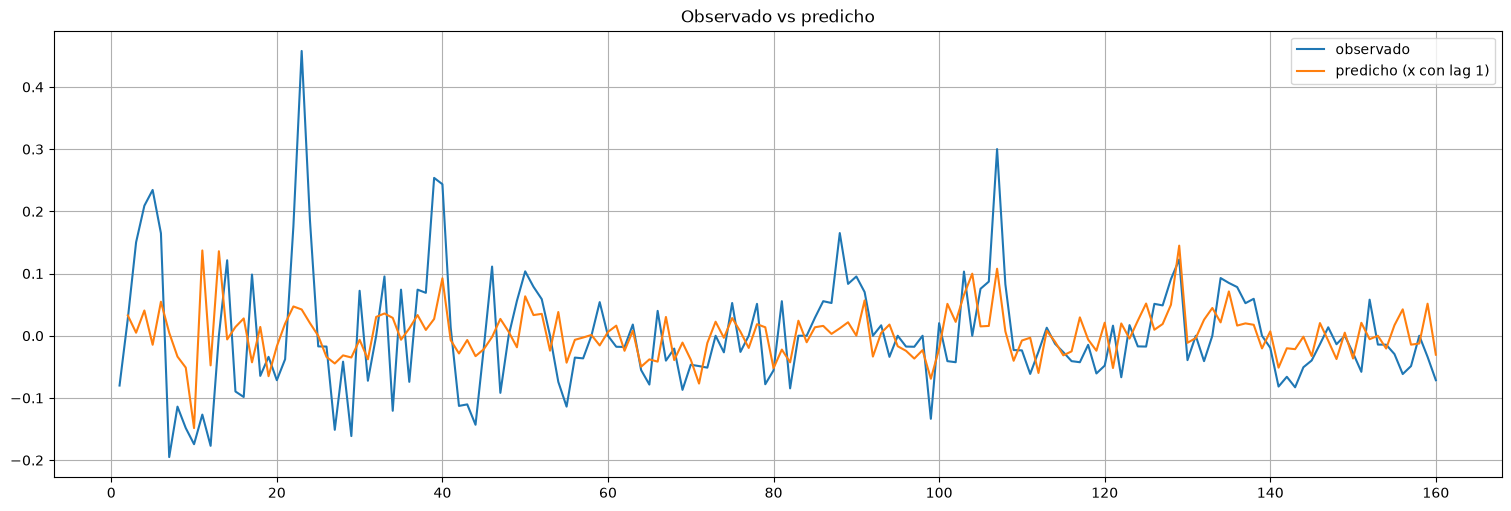

In [47]:
ax = df.unemp.dropna().plot(label='observado')
fit_propuesto.fittedvalues.plot(ax=ax, label=f'predicho (x con lag {l_opt})')
ax.legend()
ax.set_title('Observado vs predicho');

6. Analice los residuos del modelo y discuta si aún queda información por ajustar.

<Axes: >

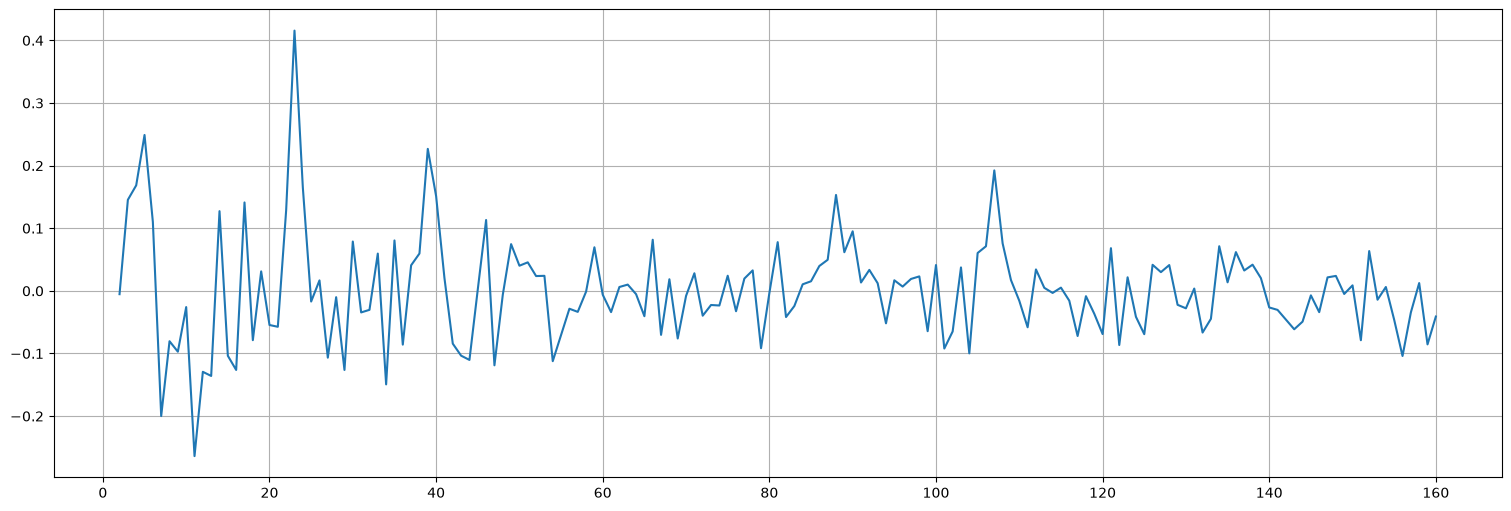

In [48]:
fit_propuesto.resid.plot(label='residuales')

In [49]:
fit_propuesto.resid.mean()

np.float64(-1.1172055593712268e-17)

Estan centrados en 0

[]

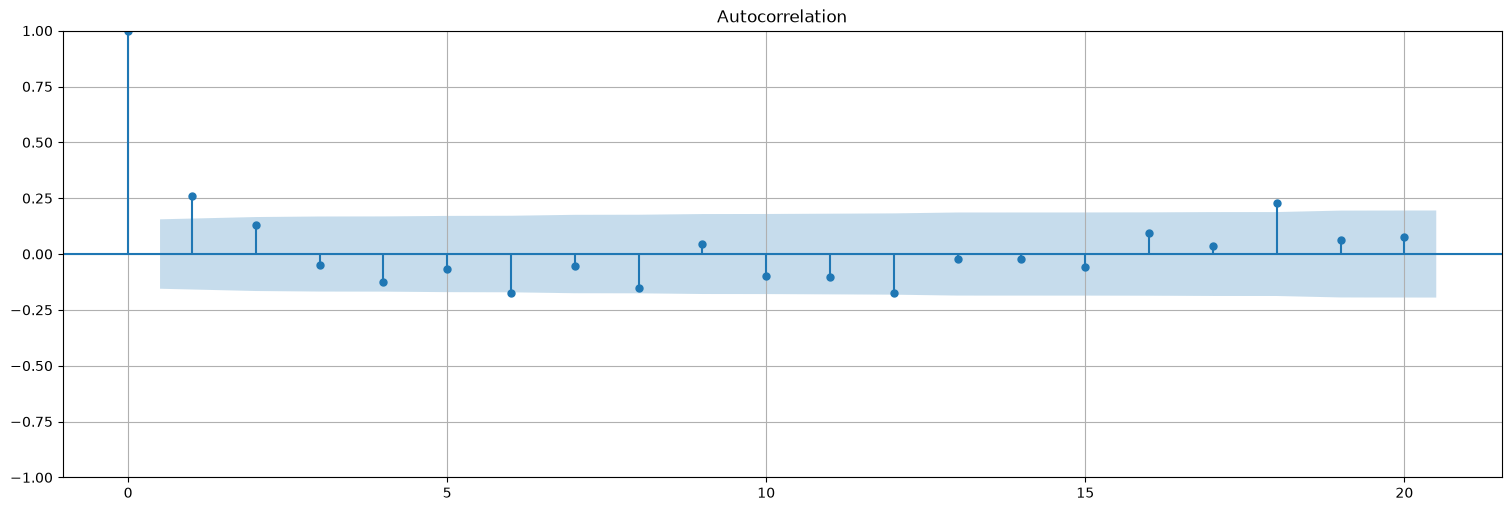

In [50]:
plot_acf(fit_propuesto.resid,lags=20)
plt.plot()

In [51]:
print(sm.stats.acorr_ljungbox(fit_propuesto.resid, lags=[1, 18, 20]))

      lb_stat  lb_pvalue
1   10.945850   0.000938
18  48.103097   0.000145
20  49.966057   0.000224


ACF sugiere que sigue habiendo autocorrelacion en el lag 1 y el 18, confirmado por Ljung-Box: p=0.0009 (lag 1), p=0.0001 (lag 18) y p=0.0002 (lag 20) -- rechaza ruido blanco con claridad en los tres horizontes, no es un caso marginal. Sigue faltando informacion por modelar: se podria agregar un termino ARMA sobre estos residuos, o mas lags de consum como regresores adicionales.